In [3]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.5 MB/s eta 0:00:00


In [4]:
# Step 1: Import Required Libraries
import os
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import xgboost as xgb
from tensorflow.keras import layers, models
import shap
import tensorflow as tf
from sklearn.metrics import accuracy_score

In [5]:
# Step 2: Load the Dataset and Inspect the First Few Rows
print("Files in CICToNIoT:")
print(os.listdir('/kaggle/input/cictoniot'))

# Assuming 'CIC-ToN-IoT-V2.parquet' contains the necessary feature data
data_features = pd.read_parquet('/kaggle/input/cictoniot/CIC-ToN-IoT-V2.parquet')
print("Dataset Loaded. First 5 rows:")
print(data_features.head())

Files in CICToNIoT:
['CIC-ToN-IoT-V2.parquet', 'CICFLowMeter Features.csv']
Dataset Loaded. First 5 rows:
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         0       47814343                  5                       0   
1         0        2033142                  2                       0   
2         0       82877133                 14                       0   
3         0          24359                  2                       0   
4         0       10239351                  3                       0   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                       0.0                       0.0                    0.0   
1                       0.0                       0.0                    0.0   
2                       0.0                       0.0                    0.0   
3                       0.0                       0.0                    0.0   
4                       0.0                       0.0  

In [7]:

# Step 3: Data Preprocessing
# Handle missing values in the target label 'Label' and remove any rows with missing 'Label'
data_features = data_features.dropna(subset=['Label'])

# Define Features and Target
X = data_features.drop(columns=['Label', 'Attack'])  # Features (dropping Label and Attack columns)
y = data_features['Label']  # Target (Label column)

# Check if there are any NaN values in target 'y'
print("NaN values in target 'y':", y.isna().sum())  # Should print 0
print("Unique values in target:", y.unique())  # Should print [0, 1] if successful

# Step 5: Check for missing values in features 'X'
print("NaN values in feature 'X':", X.isna().sum().sum())  # Should print 0 if no missing values


NaN values in target 'y': 0
Unique values in target: [0 1]
NaN values in feature 'X': 0


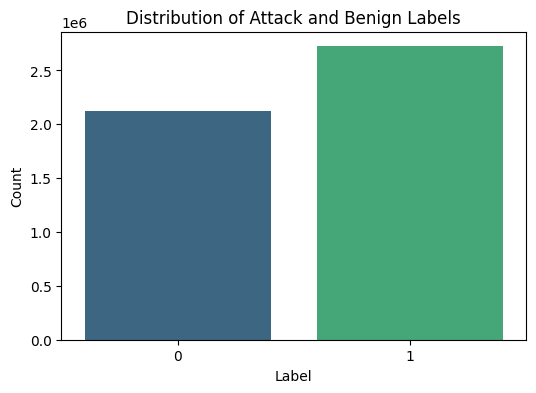

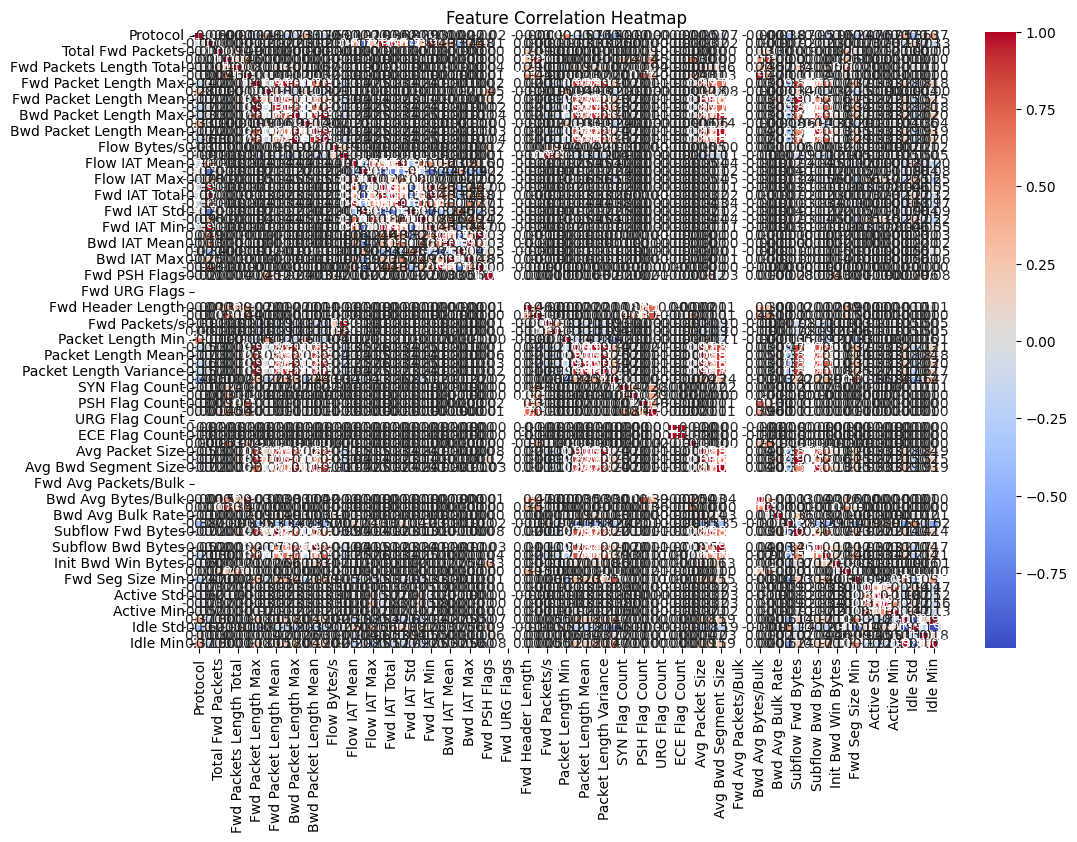

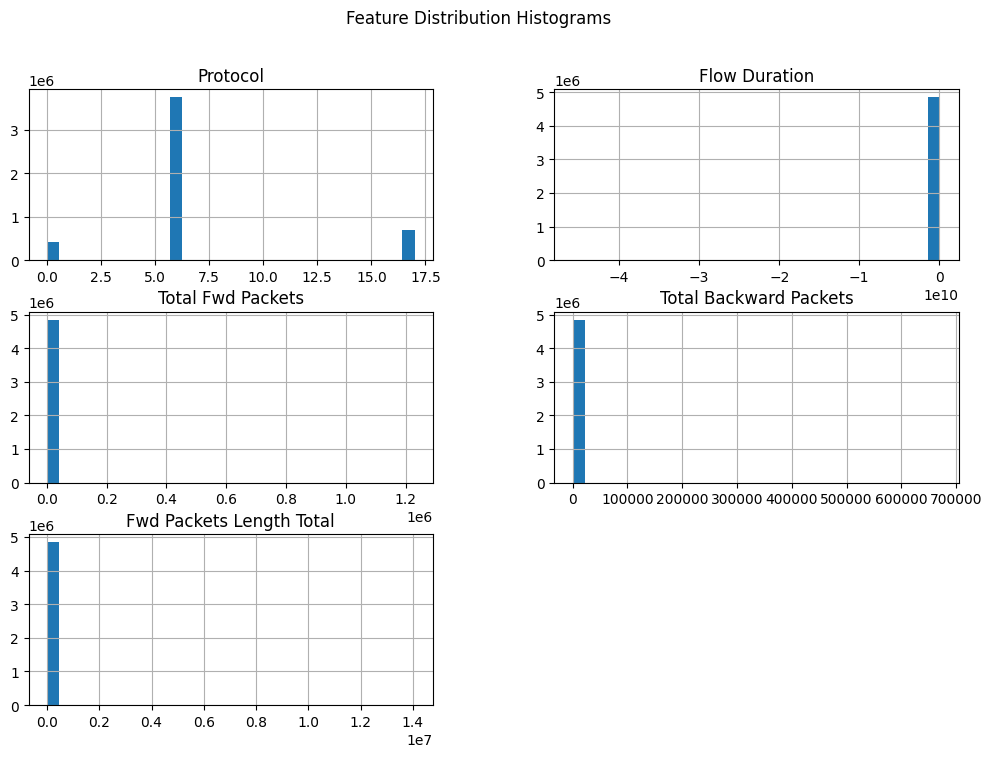

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette="viridis")
plt.title('Distribution of Attack and Benign Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Feature Correlation Heatmap
correlation_matrix = X.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


# Feature Distribution Histograms
X[['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total']].hist(bins=30, figsize=(12, 8))
plt.suptitle('Feature Distribution Histograms')
plt.show()



In [9]:
# Step 4: Scaling the Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Step 5: Split Data into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
Graph is not fully connected, spectral embedding may not work as expected.


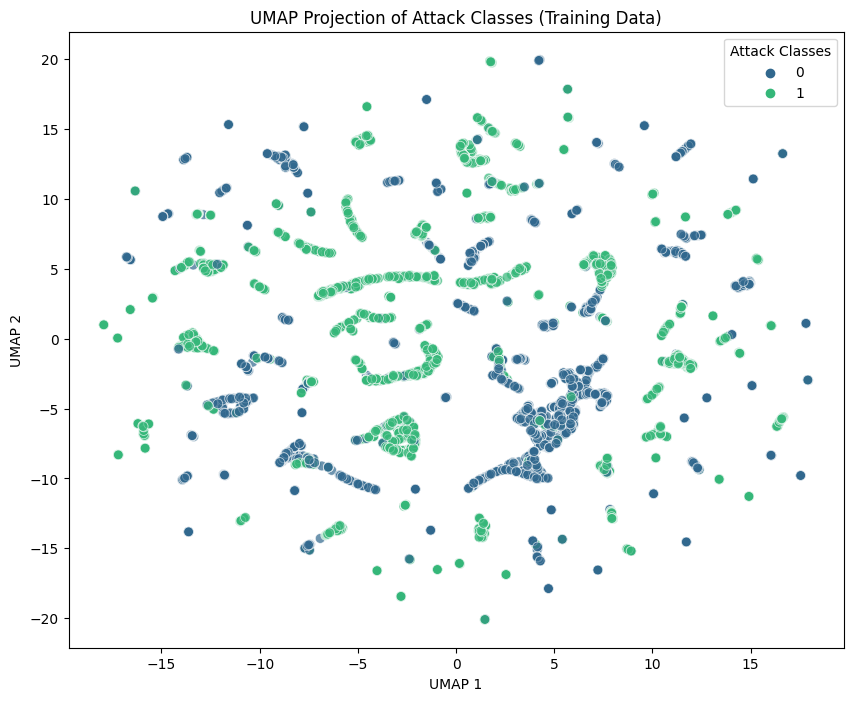

In [14]:
# Step 6: UMAP for Dimensionality Reduction (2D Visualization)
# Reduce the number of neighbors and min_dist to smaller values
umap_model = umap.UMAP(n_neighbors=10, min_dist=0.05, n_components=2, random_state=42, n_jobs=-1)
umap_train_data = umap_model.fit_transform(X_train[:10000])  # Only use a subset of data for UMAP (e.g., 10,000 samples)

# Plotting UMAP projection for attack classes
plt.figure(figsize=(10, 8))
sns.scatterplot(x=umap_train_data[:, 0], y=umap_train_data[:, 1], hue=y_train[:10000], palette='viridis', s=50, alpha=0.7)
plt.title('UMAP Projection of Attack Classes (Training Data)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Attack Classes')
plt.show()

In [11]:
# Step 7: Reshape Data for CNN Input
X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

#Verify Splitting
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Verify the reshaping
print(f"Reshaped X_train shape: {X_train_reshaped.shape}")
print(f"Reshaped X_test shape: {X_test_reshaped.shape}")

Training set size: 3877999
Testing set size: 969500
Reshaped X_train shape: (3877999, 77, 1)
Reshaped X_test shape: (969500, 77, 1)


In [12]:
# Check if there are any NaN values in the data
print("NaN values in X_train:", np.isnan(X_train).sum())
print("NaN values in y_train:", np.isnan(y_train).sum())

NaN values in X_train: 0
NaN values in y_train: 0


In [13]:
from tensorflow.keras import layers, models

# Step 8: Build Model (CNN + BiGRU)
def build_model(input_shape):
    model = models.Sequential()

    # CNN Layer for feature extraction
    model.add(layers.Conv1D(64, 3, activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling1D(2))
    model.add(layers.Conv1D(128, 3, activation='relu'))
    model.add(layers.MaxPooling1D(2))

    # BiGRU Layer for sequential data modeling
    model.add(layers.Bidirectional(layers.GRU(128, return_sequences=True)))
    model.add(layers.Bidirectional(layers.GRU(128)))

    # Flatten the output of the BiGRU before feeding it to Dense layers
    model.add(layers.Flatten())

    # Fully Connected (Dense) Layer for Classification
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))  # Binary classification, use softmax for multi-class

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build the model with dynamic input shape
model = build_model((X_train_reshaped.shape[1], 1))

# Summary of the model
model.summary()


Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 75, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 35, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 17, 256)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,065 (2.04 MB)

 Trainable params: 536,065 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 9: Train the Model
history = model.fit(X_train_reshaped, y_train, epochs=5, batch_size=32, validation_data=(X_test_reshaped, y_test))

Epoch 1/5
121188/121188 ━━━━━━━━━━━━━━━━━━━━ 1308s 11ms/step - accuracy: 0.9732 - loss: 0.0962 - val_accuracy: 0.9822 - val_loss: 0.0705
Epoch 2/5
121188/121188 ━━━━━━━━━━━━━━━━━━━━ 1301s 11ms/step - accuracy: 0.9817 - loss: 0.0714 - val_accuracy: 0.9803 - val_loss: 0.0759
Epoch 3/5
121188/121188 ━━━━━━━━━━━━━━━━━━━━ 1329s 11ms/step - accuracy: 0.9803 - loss: 0.0754 - val_accuracy: 0.9794 - val_loss: 0.0779
Epoch 4/5
121188/121188 ━━━━━━━━━━━━━━━━━━━━ 1360s 11ms/step - accuracy: 0.9793 - loss: 0.0781 - val_accuracy: 0.9789 - val_loss: 0.0789
Epoch 5/5
 22149/121188 ━━━━━━━━━━━━━━━━━━━━ 16:50 10ms/step - accuracy: 0.9784 - loss: 0.0807

In [ ]:
# Step 10: Evaluate Model
test_loss, test_acc = model.evaluate(X_test_reshaped, y_test)
print(f"Test Accuracy: {test_acc}")
print(f"Test Loss: {test_loss}")

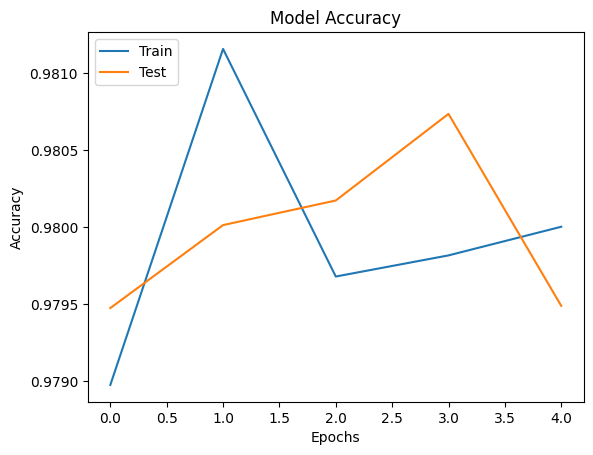

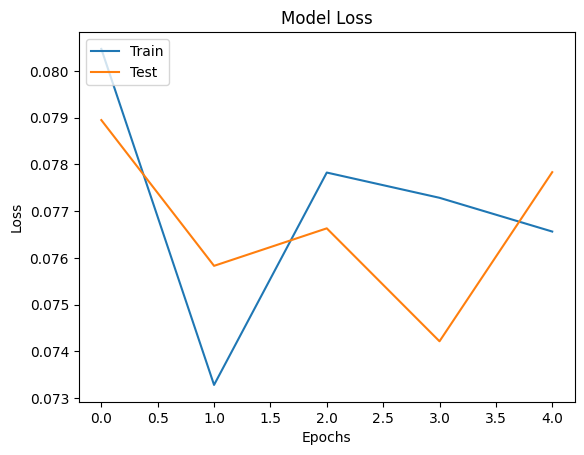

In [19]:
# Step 11: Model Performance Visualization
# Plot Training & Validation Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot Training & Validation Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


In [20]:
# Step 12: Confusion Matrix and Classification Report
y_pred = (model.predict(X_test_reshaped) > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred))


30297/30297 ━━━━━━━━━━━━━━━━━━━━ 94s 3ms/step
Confusion Matrix:
[[410962  13552]
 [  6335 538651]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    424514
           1       0.98      0.99      0.98    544986

    accuracy                           0.98    969500
   macro avg       0.98      0.98      0.98    969500
weighted avg       0.98      0.98      0.98    969500



30297/30297 ━━━━━━━━━━━━━━━━━━━━ 93s 3ms/step


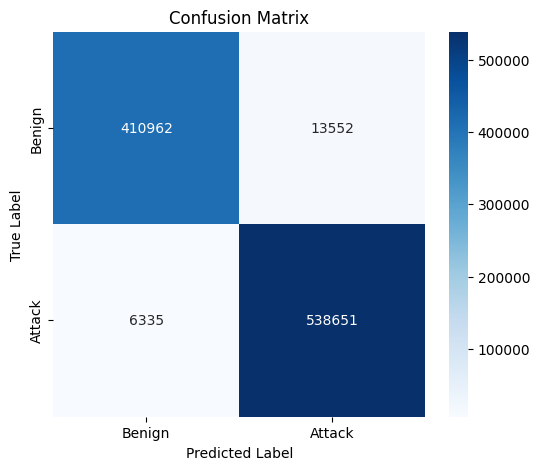

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    424514
           1       0.98      0.99      0.98    544986

    accuracy                           0.98    969500
   macro avg       0.98      0.98      0.98    969500
weighted avg       0.98      0.98      0.98    969500



In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Predict the labels
y_pred = (model.predict(X_test_reshaped) > 0.5)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


30297/30297 ━━━━━━━━━━━━━━━━━━━━ 92s 3ms/step
AUC: 0.9934086560499901


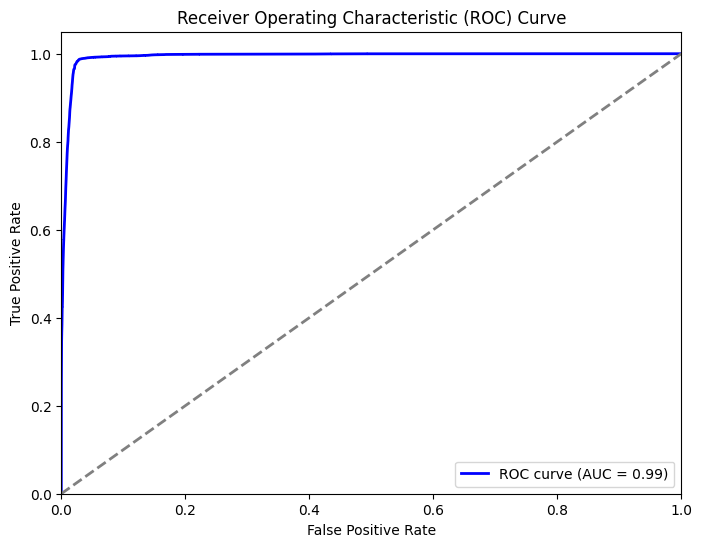

In [22]:
# Step 13: ROC Curve and AUC
y_pred_prob = model.predict(X_test_reshaped)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [25]:
# Step 14: Integrated Gradients for Feature Attribution
# Use Integrated Gradients for deep learning model interpretability
def integrated_gradients(model, input_data, baseline=None):
    if baseline is None:
        baseline = np.zeros_like(input_data)
    input_data = tf.convert_to_tensor(input_data)
    baseline = tf.convert_to_tensor(baseline)

    # Define the method and get attributions
    ig = tf.keras.applications.vgg16.integrated_gradients.IntegratedGradients(model)
    attributions = ig.explain(input_data, baseline, target_class=0)
    return attributions

In [28]:
! pip install tf-explain

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00


invalid value encountered in divide


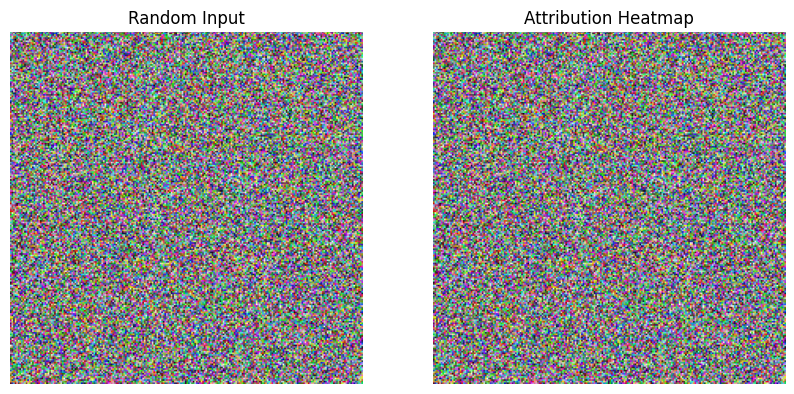

In [31]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tf_explain.core.integrated_gradients import IntegratedGradients
import cv2

# Visualization Function (same as before)
def visualize_attributions(input_data, attributions):
    # Normalize the attributions for visualization
    attributions = np.abs(attributions)  # Absolute value to show impact
    attributions = np.sum(attributions, axis=-1)  # Sum over color channels (RGB)

    # Normalize between 0 and 1
    attributions = (attributions - np.min(attributions)) / (np.max(attributions) - np.min(attributions))

    # Resize the attribution map to match the image size
    attributions_resized = cv2.resize(attributions, (input_data.shape[1], input_data.shape[0]))

    # Plot original image and overlay the attribution heatmap
    plt.figure(figsize=(10, 10))

    # Random image
    plt.subplot(1, 2, 1)
    plt.imshow(input_data)
    plt.title("Random Input")
    plt.axis('off')

    # Attributions heatmap
    plt.subplot(1, 2, 2)
    plt.imshow(input_data)
    plt.imshow(attributions_resized, cmap='jet', alpha=0.5)  # Overlay heatmap
    plt.title("Attribution Heatmap")
    plt.axis('off')

    plt.show()

# Example Usage with Random Noise
# Create a random input (noise image)
random_image = np.random.rand(224, 224, 3)  # Random noise image of size 224x224x3

# Load pre-trained model (e.g., VGG16)
model = tf.keras.applications.VGG16(weights='imagenet')

# Preprocess the random image (add batch dimension)
random_image_input = np.expand_dims(random_image, axis=0).astype(np.float32)

# Initialize Integrated Gradients
ig = IntegratedGradients()

# Correct usage of the explain method
attributions = ig.explain(
    validation_data=(random_image_input, None),  # Validation data is the input image, target class is None
    model=model,
    class_index=None  # Set class_index to None to explain for the top predicted class
)

# Visualize the result
visualize_attributions(random_image, attributions)


In [32]:
# Step 16: Ensemble Learning (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate the Random Forest Model
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy}")

rf_cm = confusion_matrix(y_test, rf_predictions)
print("Random Forest Confusion Matrix:")
print(rf_cm)
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.9930386797318205
Random Forest Confusion Matrix:
[[419165   5349]
 [  1400 543586]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    424514
           1       0.99      1.00      0.99    544986

    accuracy                           0.99    969500
   macro avg       0.99      0.99      0.99    969500
weighted avg       0.99      0.99      0.99    969500



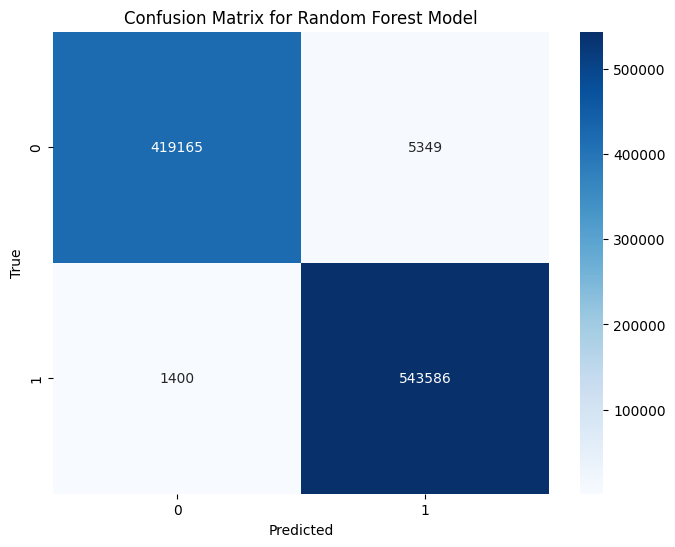

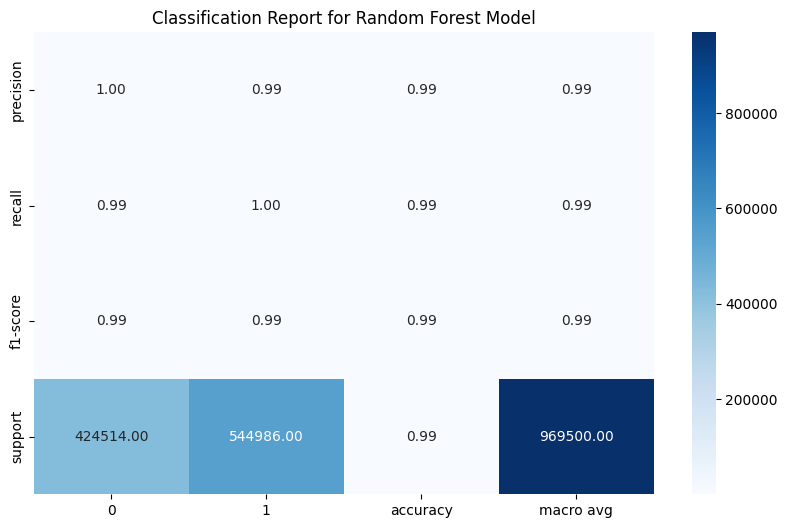

In [33]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Calculate confusion matrix for Random Forest model
rf_cm = confusion_matrix(y_test, rf_predictions)

# Plot the confusion matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix for Random Forest Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Step 2: Generate the classification report for Random Forest model
rf_class_report = classification_report(y_test, rf_predictions, output_dict=True)

# Convert the classification report dictionary to pandas DataFrame
import pandas as pd
rf_report_df = pd.DataFrame(rf_class_report).transpose()

# Plot the classification report as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(rf_report_df.iloc[:-1, :].T, annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report for Random Forest Model")
plt.show()


In [1]:
# Import necessary libraries
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# Step 17: Stacking Ensemble
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', xgb.XGBClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(probability=True, random_state=42))  # Ensure SVC is imported
]

meta_learner = LogisticRegression()

stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)
stacking_model.fit(X_train, y_train)

stacking_predictions = stacking_model.predict(X_test)

stacking_accuracy = accuracy_score(y_test, stacking_predictions)
print(f"Stacking Model Accuracy: {stacking_accuracy}")

stacking_cm = confusion_matrix(y_test, stacking_predictions)
print("Stacking Model Confusion Matrix:")
print(stacking_cm)

print("Stacking Model Classification Report:")
print(classification_report(y_test, stacking_predictions))


NameError: name 'X_train' is not defined

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Visualizing the Confusion Matrix
stacking_cm = confusion_matrix(y_test, stacking_predictions)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(stacking_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix for Stacking Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Visualizing the Classification Report as a Heatmap
class_report = classification_report(y_test, stacking_predictions, output_dict=True)

# Convert the classification report dictionary to a pandas DataFrame
import pandas as pd
report_df = pd.DataFrame(class_report).transpose()

# Plot the classification report as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report for Stacking Model")
plt.show()


In [ ]:
# Step 19: Save the Model
model.save('model.h5')
print("Model saved as 'model.h5'")

# Complete Code for Benchmarking, Comparison, and Model Interpretability

In [ ]:
# Import necessary libraries
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import shap
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# Step 1: Train Baseline Models
# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Step 2: Evaluate Baseline Models
# Logistic Regression Evaluation
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))
print("Logistic Regression AUC:", roc_auc_score(y_test, y_pred_logreg))

# Decision Tree Evaluation
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Decision Tree AUC:", roc_auc_score(y_test, y_pred_dt))

# Random Forest Evaluation
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest AUC:", roc_auc_score(y_test, y_pred_rf))

# Step 3: Train and Evaluate Advanced Model (Assumed as 'model')
# Assuming 'model' is a deep learning model you've already trained.
# Evaluate the advanced model (neural network)
y_pred_advanced = (model.predict(X_test_reshaped) > 0.5)

print("Advanced Model Classification Report:")
print(classification_report(y_test, y_pred_advanced))
print("Advanced Model AUC:", roc_auc_score(y_test, y_pred_advanced))

# Step 4: Benchmark Comparison (Advanced vs Baselines)
# Print all the results to compare
print("\nBenchmarking Results Comparison:")
print(f"Logistic Regression AUC: {roc_auc_score(y_test, y_pred_logreg)}")
print(f"Decision Tree AUC: {roc_auc_score(y_test, y_pred_dt)}")
print(f"Random Forest AUC: {roc_auc_score(y_test, y_pred_rf)}")
print(f"Advanced Model AUC: {roc_auc_score(y_test, y_pred_advanced)}")

# Step 5: Model Interpretability - SHAP for Deep Learning Model
# Create SHAP Explainer for the advanced model
explainer = shap.KernelExplainer(model.predict, X_train[:100])  # Use subset of data for SHAP
shap_values = explainer.shap_values(X_test[:10])  # Explain predictions for test data

# Visualize SHAP summary plot
shap.summary_plot(shap_values, X_test[:10])

# Step 6: Model Interpretability - LIME for Local Explanations
# Initialize LIME explainer for model interpretation
explainer_lime = LimeTabularExplainer(X_train, training_labels=y_train, mode='classification')

# Choose an instance to explain (first instance of test set)
exp = explainer_lime.explain_instance(X_test[0], model.predict_proba)

# Show explanation in notebook (you can visualize the results)
exp.show_in_notebook()

# Step 7: Visualize Feature Importance (using SHAP or LIME summary)
# SHAP Summary Plot (Global Explanation)
shap.summary_plot(shap_values, X_test)  # This will show how each feature contributes to predictions.

# Optional: Visualize confusion matrix for advanced model to see class distribution
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix for Advanced Model
cm = confusion_matrix(y_test, y_pred_advanced)

# Plotting confusion matrix using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()